In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

In [38]:
X, y = datasets.make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.5)

In [39]:
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (6,6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

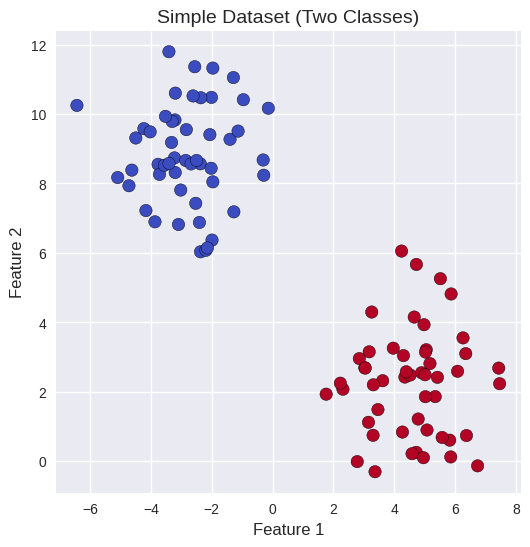

In [40]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', s=80, edgecolors='k')
plt.title("Simple Dataset (Two Classes)", fontsize=14)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

In [41]:
model = SVC(kernel='linear')
model.fit(X, y)

SVC(kernel='linear')

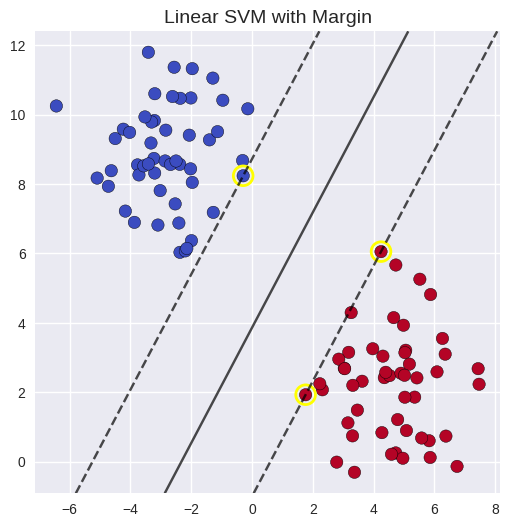

In [42]:
def plot_svm(model, X, y):
    plt.figure(figsize=(6,6))
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', s=80, edgecolors='k')

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = model.decision_function(xy).reshape(XX.shape)
    ax.contour(XX, YY, Z, colors='black',
               levels=[-1, 0, 1], alpha=0.7,
               linestyles=['--', '-', '--'])
    ax.scatter(model.support_vectors_[:,0],
               model.support_vectors_[:,1],
               s=200, linewidth=2,
               facecolors='none', edgecolors='yellow')
    plt.title("Linear SVM with Margin", fontsize=14)
    plt.grid(True)
    plt.show()
plot_svm(model, X, y)

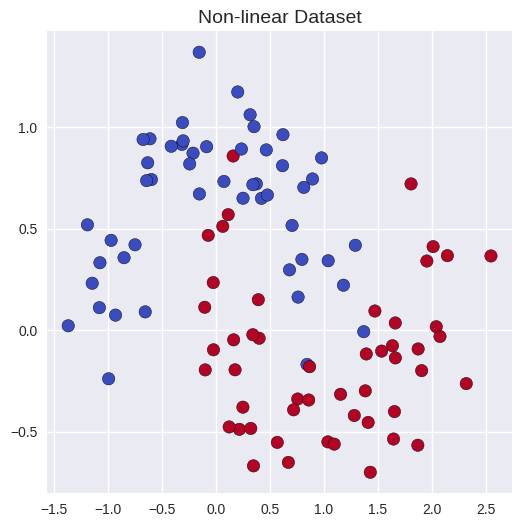

In [44]:
X2, y2 = datasets.make_moons(n_samples=100, noise=0.2, random_state=42)

plt.figure(figsize=(6,6))
plt.scatter(X2[:,0], X2[:,1], c=y2, cmap='coolwarm', s=80, edgecolors='k')
plt.title("Non-linear Dataset", fontsize=14)
plt.grid(True)
plt.show()

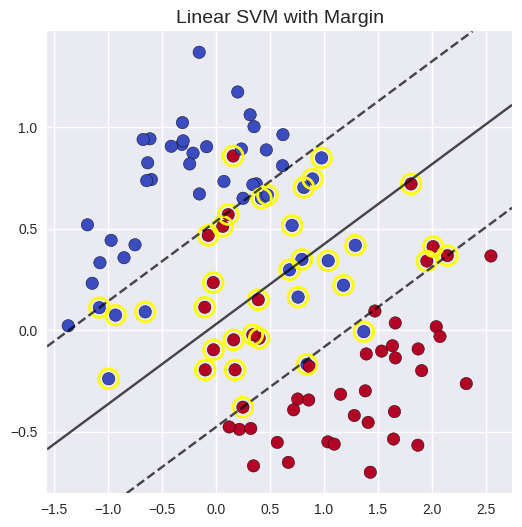

In [45]:
model_linear = SVC(kernel='linear')
model_linear.fit(X2, y2)

plot_svm(model_linear, X2, y2)

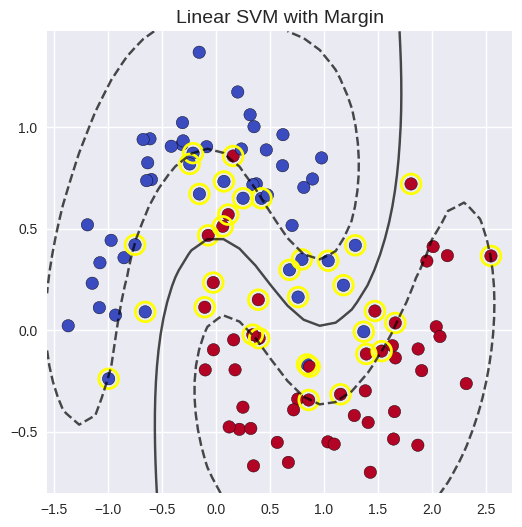

In [46]:
model_rbf = SVC(kernel='rbf', gamma=1)
model_rbf.fit(X2, y2)

plot_svm(model_rbf, X2, y2)

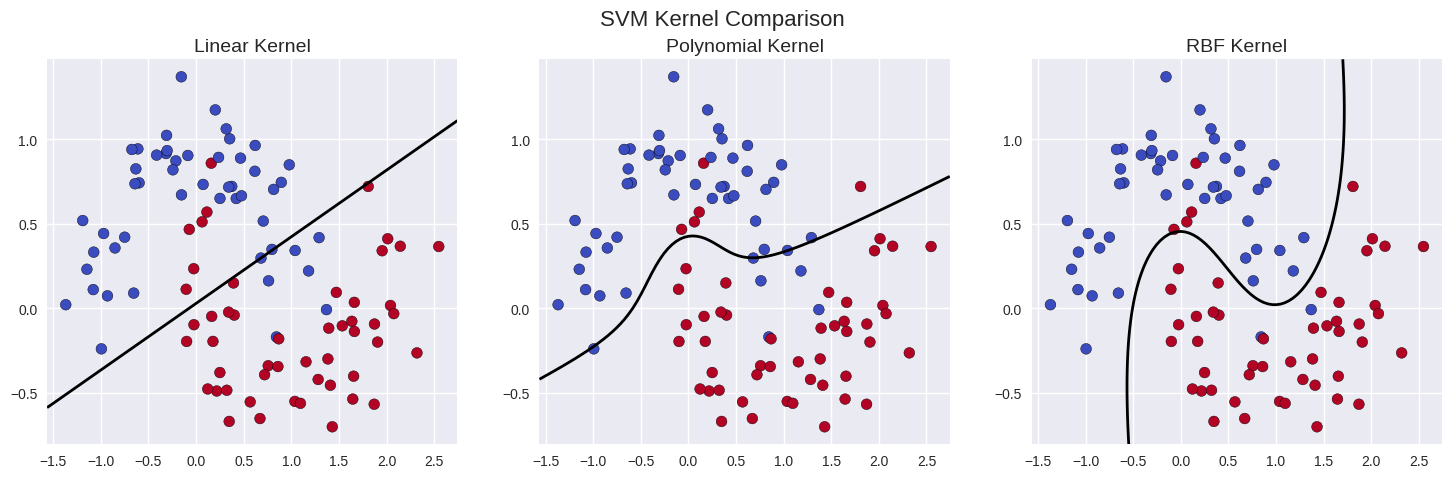

In [47]:
models = [
    ("Linear", SVC(kernel='linear', C=1)),
    ("Polynomial", SVC(kernel='poly', degree=3, C=1)),
    ("RBF", SVC(kernel='rbf', gamma=1, C=1))
]

plt.figure(figsize=(18,5))

for i, (name, model) in enumerate(models):
    plt.subplot(1, 3, i+1)

    model.fit(X2, y2)
    plt.scatter(X2[:,0], X2[:,1], c=y2, cmap='coolwarm', s=60, edgecolors='k')

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = model.decision_function(xy).reshape(XX.shape)

    ax.contour(XX, YY, Z, levels=[0], colors='black', linewidths=2)

    plt.title(f"{name} Kernel", fontsize=14)
    plt.grid(True)

plt.suptitle("SVM Kernel Comparison", fontsize=16)
plt.show()

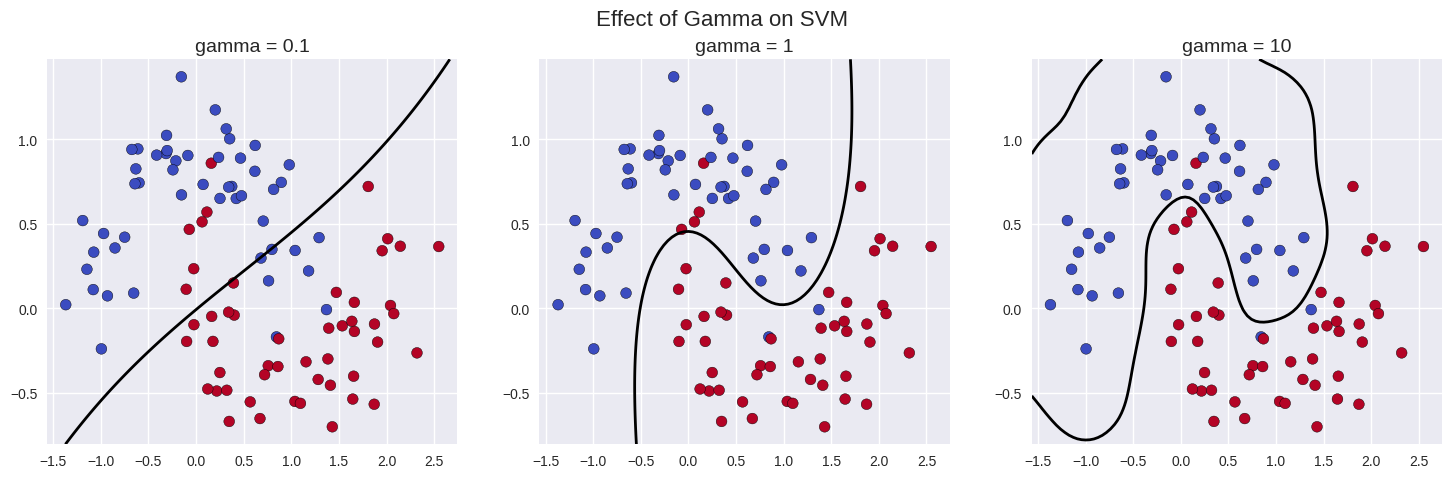

In [48]:
gammas = [0.1, 1, 10]

plt.figure(figsize=(18,5))

for i, g in enumerate(gammas):
    plt.subplot(1, 3, i+1)

    model = SVC(kernel='rbf', gamma=g)
    model.fit(X2, y2)

    plt.scatter(X2[:,0], X2[:,1], c=y2, cmap='coolwarm', s=60, edgecolors='k')

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = model.decision_function(xy).reshape(XX.shape)

    ax.contour(XX, YY, Z, levels=[0], colors='black', linewidths=2)

    plt.title(f"gamma = {g}", fontsize=14)
    plt.grid(True)

plt.suptitle("Effect of Gamma on SVM", fontsize=16)
plt.show()

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.3, random_state=42)

In [50]:
from sklearn.metrics import accuracy_score

model = SVC(kernel='rbf', gamma=1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9666666666666667


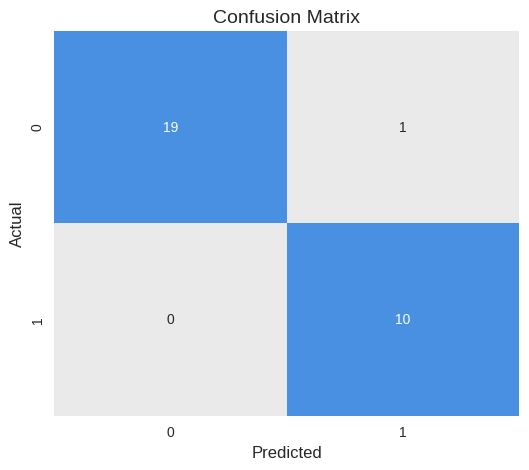

In [54]:
from matplotlib.colors import ListedColormap

# Define two colors (e.g., blue and light gray)
cmap = ListedColormap(["#EAEAEA","#4A90E2"])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False)

plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [52]:
models = {
    "Linear": SVC(kernel='linear'),
    "Polynomial": SVC(kernel='poly', degree=3),
    "RBF": SVC(kernel='rbf', gamma=1)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.2f}")

Linear Accuracy: 0.87
Polynomial Accuracy: 0.83
RBF Accuracy: 0.97
